# Labour Market Shockwaves
## A Regional Diagnostic of India's Unemployment Before and During COVID-19
### Complete Project Jupyter Notebook — Phase 13

**Dataset:** `Unemployment in India(1).csv`  
**Coverage:** May 2019 – June 2020  
**Analytical focus:** National unemployment, regional heterogeneity, Rural vs Urban differences, statistical evidence, anomaly detection, time-series diagnostics, clustering, and scoped forecasting.

### Project objective

This notebook reconstructs the complete analytical workflow developed across Phases 1–12 in one reproducible document.

The notebook follows:

**Data Loading → Data Understanding → Data Cleaning → Data Preparation → EDA → Visualizations → Statistical Analysis → Regional Profiling → Clustering → Anomaly Detection → Time-Series Diagnostics → Forecasting → Insights → Conclusions**

### Main analytical questions

1. How did unemployment change between the Pre-COVID and COVID periods?
2. How heterogeneous were the effects across Indian regions?
3. Did Rural and Urban unemployment distributions differ?
4. What relationships between unemployment, participation, and employment are supported by the data?
5. Which observations are statistical anomalies, and how do they relate to the COVID shock?
6. What time-series structure can reasonably be inferred from only 14 monthly observations?
7. Can short-horizon forecasting benchmarks be evaluated without overstating predictive reliability?

> **Important:** This is an observational analysis. Correlation and group differences do not establish causation.

## 2. Import Libraries

Only libraries used in the notebook are imported.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
COVID_START = pd.Timestamp("2020-03-01")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Dataset

The notebook uses a relative path so it can be moved as a project folder and executed without changing an absolute local path.

In [2]:
DATA_PATH = Path("data") / "Unemployment in India(1).csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Run the notebook from the project root containing the data/ folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (768, 7)


In [3]:
display(df.head())
display(df.tail())
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data types:


,dtype
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


## 4. Data Understanding

### Initial inspection

In [4]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

Shape: (768, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,14,31-10-2019,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequency,740,2,Monthly,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,10.721298,0.0,4.6575,8.35,15.8875,76.74
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,8087988.429458,49420.0,1190404.5,4744178.5,11275489.5,45777509.0
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,8.111094,13.33,38.0625,41.16,45.505,72.57
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Unique values by column:")
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:20])

Unique values by column:

Region
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan']

 Date
[' 31-05-2019' ' 30-06-2019' ' 31-07-2019' ' 31-08-2019' ' 30-09-2019'
 ' 31-10-2019' ' 30-11-2019' ' 31-12-2019' ' 31-01-2020' ' 29-02-2020'
 ' 31-03-2020' ' 30-04-2020' ' 31-05-2020' ' 30-06-2020' nan]

 Frequency
[' Monthly' nan 'Monthly']

 Estimated Unemployment Rate (%)
[ 3.65  3.05  3.75  3.32  5.17  3.52  4.12  4.38  4.84  5.91  4.06 16.29
 14.46  0.85  4.29  5.08  4.26  5.79  4.46  4.65]

 Estimated Employed
[11999139. 11755881. 12086707. 12285693. 12256762. 12017412. 11397681.
 12528395. 12016676. 11723617. 11359660.  8792827.  9526902. 15572975.
 11749334.  8923222.  9911534.  9292039. 11468349.  8395906.]

 Estimated Labour Participation Rate (%)
[43.24 42.05 43.5  43.97 44.68 43.01 41.   45.14 4

In [7]:
missing_before = df.isna().sum().sort_values(ascending=False)
duplicate_rows_before = df.duplicated().sum()

print("Missing values:")
display(missing_before.to_frame("missing_count"))

print("Duplicate full rows:", duplicate_rows_before)

Missing values:


,missing_count
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


Duplicate full rows: 27


### Initial findings

The raw dataset contains fully blank trailing rows. These are not analytical observations and are removed during cleaning.

The original fields contain whitespace that should be normalized before analysis. Dates also need explicit parsing.

## 5. Data Cleaning

Every important transformation is shown explicitly.

In [8]:
# Keep an untouched copy of the raw data for auditability.
raw_df = df.copy()

# 1. Strip whitespace from column names.
df.columns = df.columns.str.strip()

# 2. Strip whitespace from string values.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


### Remove fully blank rows

The raw file contains 28 rows where every field is blank. They are removed because they do not represent observations.

In [9]:
blank_row_mask = df.isna().all(axis=1)
blank_rows_removed = int(blank_row_mask.sum())

df = df.loc[~blank_row_mask].copy()

print("Fully blank rows removed:", blank_rows_removed)
print("Shape after removing fully blank rows:", df.shape)

Fully blank rows removed: 28
Shape after removing fully blank rows: (740, 7)


### Convert the date field

The `Date` field is converted to a proper datetime type. Invalid dates are counted explicitly rather than silently ignored.

In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

date_parse_failures = int(df["Date"].isna().sum())
print("Date parsing failures:", date_parse_failures)

if date_parse_failures:
    raise ValueError("Date parsing produced invalid dates.")

Date parsing failures: 0


### Convert numeric fields

The three numeric analytical variables are explicitly converted to numeric values. Conversion failures are checked.

In [11]:
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

conversion_missing = df[numeric_cols].isna().sum()

print("Numeric conversion missing counts:")
display(conversion_missing.to_frame("count"))

if conversion_missing.sum() > 0:
    raise ValueError("Numeric conversion created missing values.")

Numeric conversion missing counts:


,count
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0


### Standardize categorical fields

The analysis uses `Region` and `Area` as categorical dimensions. Whitespace has already been removed; we also inspect the resulting unique values.

In [12]:
df["Region"] = df["Region"].astype(str).str.strip()
df["Area"] = df["Area"].astype(str).str.strip()

print("Areas:", sorted(df["Area"].unique().tolist()))
print("Number of regions:", df["Region"].nunique())

Areas: ['Rural', 'Urban']
Number of regions: 28


### Create the analytical period

The project defines:

- **Pre-COVID:** May 2019 through February 2020
- **COVID:** March 2020 through June 2020

This is a project-defined analytical split, not a causal boundary.

In [13]:
df["Period"] = np.where(
    df["Date"] < COVID_START,
    "Pre-COVID",
    "COVID"
)

print(df["Period"].value_counts())

Period
Pre-COVID    536
COVID        204
Name: count, dtype: int64


### Remove exact duplicates only if they exist

The project checks duplicate Region-Date-Area combinations. No duplicates are expected after validation.

In [14]:
duplicate_key_mask = df.duplicated(
    subset=["Region", "Date", "Area"],
    keep=False
)

duplicate_key_count = int(duplicate_key_mask.sum())

print("Duplicate Region-Date-Area observations:", duplicate_key_count)

if duplicate_key_count > 0:
    display(
        df.loc[duplicate_key_mask]
        .sort_values(["Region", "Date", "Area"])
    )
else:
    print("No duplicate Region-Date-Area combinations found.")

Duplicate Region-Date-Area observations: 0
No duplicate Region-Date-Area combinations found.


### Outlier policy

The project does **not** delete extreme unemployment observations merely because they are large.

The April–May 2020 extremes are treated as legitimate COVID shock observations. Formal anomaly detection is performed later using IQR and rolling z-score methods, with contextual classification.

## 6. Clean Dataset Validation

In [15]:
clean_df = df.copy()

validation = {
    "rows": len(clean_df),
    "columns": clean_df.shape[1],
    "missing_values": int(clean_df.isna().sum().sum()),
    "duplicate_full_rows": int(clean_df.duplicated().sum()),
    "duplicate_region_date_area": int(
        clean_df.duplicated(["Region", "Date", "Area"]).sum()
    ),
    "date_min": clean_df["Date"].min(),
    "date_max": clean_df["Date"].max(),
    "regions": clean_df["Region"].nunique(),
    "areas": clean_df["Area"].nunique(),
    "unemployment_out_of_range": int(
        ((clean_df["Estimated Unemployment Rate (%)"] < 0) |
         (clean_df["Estimated Unemployment Rate (%)"] > 100)).sum()
    ),
    "participation_out_of_range": int(
        ((clean_df["Estimated Labour Participation Rate (%)"] < 0) |
         (clean_df["Estimated Labour Participation Rate (%)"] > 100)).sum()
    ),
    "negative_employment": int(
        (clean_df["Estimated Employed"] < 0).sum()
    ),
}

display(pd.Series(validation, name="value").to_frame())

,value
rows,740
columns,8
missing_values,0
duplicate_full_rows,0
duplicate_region_date_area,0
date_min,2019-05-31 00:00:00
date_max,2020-06-30 00:00:00
regions,28
areas,2
unemployment_out_of_range,0


In [16]:
print("Final dtypes:")
display(clean_df.dtypes.to_frame("dtype"))

print("\nArea values:")
display(clean_df["Area"].value_counts().to_frame("count"))

print("\nRegion count:", clean_df["Region"].nunique())
print("Monthly dates:", clean_df["Date"].nunique())
print("Date range:", clean_df["Date"].min().date(), "to", clean_df["Date"].max().date())

Final dtypes:


,dtype
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object
Period,object



Area values:


,count
Area,
Urban,381
Rural,359



Region count: 28
Monthly dates: 14
Date range: 2019-05-31 to 2020-06-30


### Validation conclusion

The cleaned dataset contains **740 observations**, **28 regions**, **2 areas**, and **14 monthly dates**. No duplicate Region-Date-Area combinations, invalid unemployment/participation ranges, negative employment values, or internal missing values remain.

## 7. Coverage Audit

In [17]:
expected_months = pd.date_range(
    clean_df["Date"].min(),
    clean_df["Date"].max(),
    freq="ME"
)

coverage_table = (
    clean_df.groupby(["Region", "Area"])["Date"]
    .nunique()
    .reset_index(name="months_observed")
)

coverage_table["expected_months"] = len(expected_months)
coverage_table["complete"] = (
    coverage_table["months_observed"] == coverage_table["expected_months"]
)

region_coverage = (
    clean_df.groupby("Region")["Date"]
    .nunique()
    .reset_index(name="months_observed")
)

region_coverage["expected_months"] = len(expected_months)
region_coverage["complete"] = (
    region_coverage["months_observed"] == region_coverage["expected_months"]
)

display(region_coverage.sort_values(["complete", "Region"]))

,Region,months_observed,expected_months,complete
3,Chandigarh,12,14,False
6,Goa,13,14,False
10,Jammu & Kashmir,12,14,False
21,Sikkim,12,14,False
0,Andhra Pradesh,14,14,True
1,Assam,14,14,True
2,Bihar,14,14,True
4,Chhattisgarh,14,14,True
5,Delhi,14,14,True
7,Gujarat,14,14,True


In [18]:
fully_covered_regions = sorted(
    region_coverage.loc[region_coverage["complete"], "Region"].tolist()
)
incomplete_regions = sorted(
    region_coverage.loc[~region_coverage["complete"], "Region"].tolist()
)

print("Fully covered regions:", len(fully_covered_regions))
print(fully_covered_regions)
print("\nIncomplete regions:", len(incomplete_regions))
print(incomplete_regions)

Fully covered regions: 24
['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Incomplete regions: 4
['Chandigarh', 'Goa', 'Jammu & Kashmir', 'Sikkim']


For regional statistical comparisons requiring balanced coverage, the project uses the **20 fully covered regions**. Incomplete regions remain in descriptive analyses where their available observations are informative.

## 8. Exploratory Data Analysis

### 8.1 Overall descriptive statistics

In [19]:
descriptive_stats = clean_df[
    numeric_cols
].describe().T

descriptive_stats["median"] = clean_df[numeric_cols].median()
descriptive_stats["IQR"] = (
    clean_df[numeric_cols].quantile(0.75)
    - clean_df[numeric_cols].quantile(0.25)
)
descriptive_stats["skew"] = clean_df[numeric_cols].skew()

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,median,IQR,skew
Estimated Unemployment Rate (%),740.0,1.178795e+01,1.072130e+01,0.00,4.657500e+00,8.35,1.588750e+01,76.74,8.35,1.123000e+01,2.217921
Estimated Employed,740.0,7.204460e+06,8.087988e+06,49420.00,1.190404e+06,4744178.50,1.127549e+07,45777509.00,4744178.50,1.008508e+07,2.049821
Estimated Labour Participation Rate (%),740.0,4.263012e+01,8.111094e+00,13.33,3.806250e+01,41.16,4.550500e+01,72.57,41.16,7.442500e+00,1.031480


### 8.2 National monthly aggregation

In [20]:
monthly = (
    clean_df.groupby("Date")
    .agg(
        Mean_Unemployment=("Estimated Unemployment Rate (%)", "mean"),
        Median_Unemployment=("Estimated Unemployment Rate (%)", "median"),
        Mean_Participation=("Estimated Labour Participation Rate (%)", "mean"),
        Mean_Employment=("Estimated Employed", "mean"),
        Observations=("Estimated Unemployment Rate (%)", "size"),
        Regions=("Region", "nunique")
    )
    .reset_index()
    .sort_values("Date")
)

monthly["Period"] = np.where(
    monthly["Date"] < COVID_START,
    "Pre-COVID",
    "COVID"
)

display(monthly)

,Date,Mean_Unemployment,Median_Unemployment,Mean_Participation,Mean_Employment,Observations,Regions,Period
0,2019-05-31,8.874259,6.870,43.902963,7.410148e+06,54,28,Pre-COVID
1,2019-06-30,9.303333,7.570,43.750556,7.358642e+06,54,28,Pre-COVID
2,2019-07-31,9.033889,7.160,43.706667,7.404425e+06,54,28,Pre-COVID
3,2019-08-31,9.637925,7.270,43.646792,7.539815e+06,53,28,Pre-COVID
4,2019-09-30,9.051731,6.240,44.301346,7.739464e+06,52,27,Pre-COVID
5,2019-10-31,9.900909,7.290,44.001273,7.298382e+06,55,28,Pre-COVID
6,2019-11-30,9.868364,6.940,44.110545,7.273661e+06,55,28,Pre-COVID
7,2019-12-31,9.497358,7.240,43.667358,7.377388e+06,53,28,Pre-COVID
8,2020-01-31,9.950755,6.790,44.051321,7.677344e+06,53,27,Pre-COVID
9,2020-02-29,9.964717,7.550,43.723019,7.603996e+06,53,27,Pre-COVID


### 8.3 Pre-COVID vs COVID

In [21]:
period_summary = (
    clean_df.groupby("Period")["Estimated Unemployment Rate (%)"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(period_summary)

pre_mean = period_summary.loc["Pre-COVID", "mean"]
covid_mean = period_summary.loc["COVID", "mean"]
shock_pp = covid_mean - pre_mean
shock_pct = shock_pp / pre_mean * 100

print(f"Absolute change: {shock_pp:.3f} percentage points")
print(f"Relative change: {shock_pct:.3f}%")

,count,mean,median,std,min,max
Period,,,,,,
COVID,204,17.774363,14.520,15.033663,0.0,76.74
Pre-COVID,536,9.509534,7.115,7.358863,0.0,34.69


Absolute change: 8.265 percentage points
Relative change: 86.911%


## 9. Data Visualizations

### 9.1 National unemployment trend

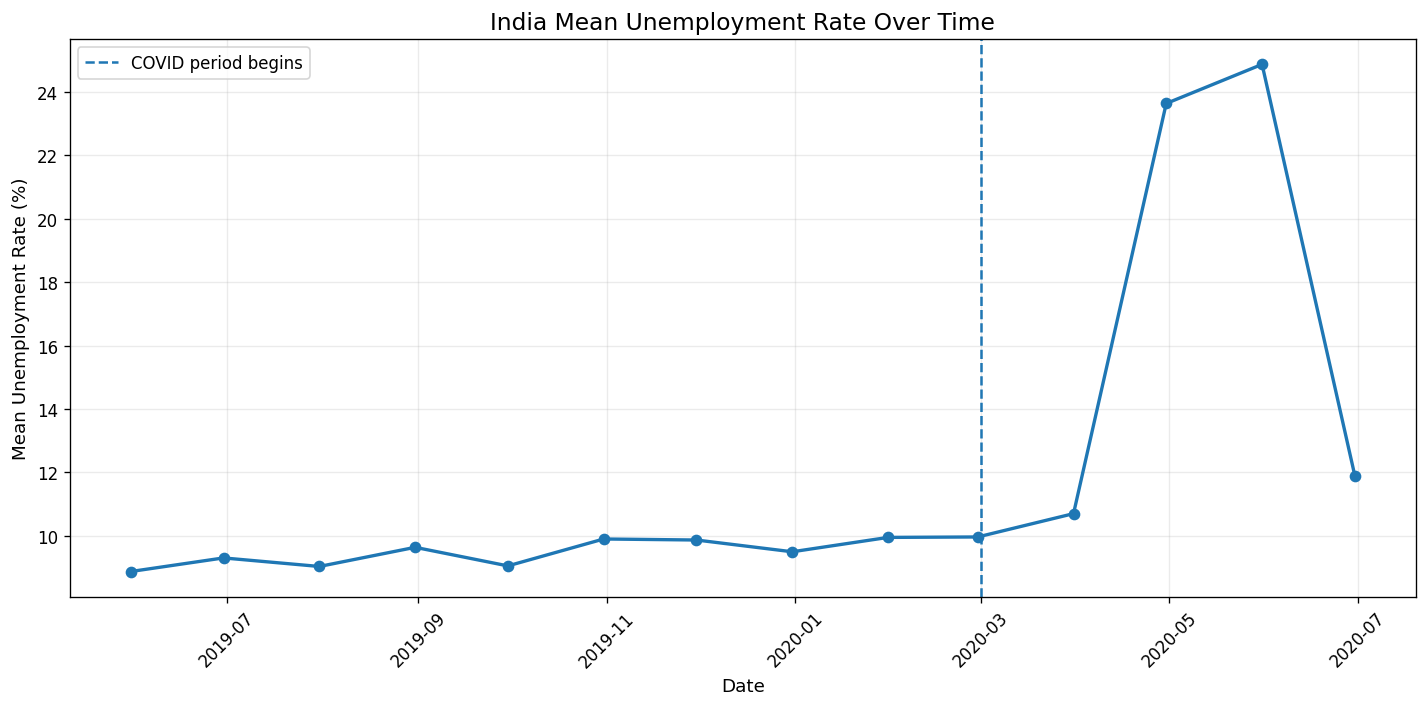

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly["Date"],
    monthly["Mean_Unemployment"],
    marker="o",
    linewidth=2
)

ax.axvline(
    COVID_START,
    linestyle="--",
    linewidth=1.5,
    label="COVID period begins"
)

ax.set_title("India Mean Unemployment Rate Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Unemployment Rate (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** National unemployment rises sharply during the COVID period, peaks in May 2020, and falls substantially by June 2020.

### 9.2 Pre-COVID vs COVID

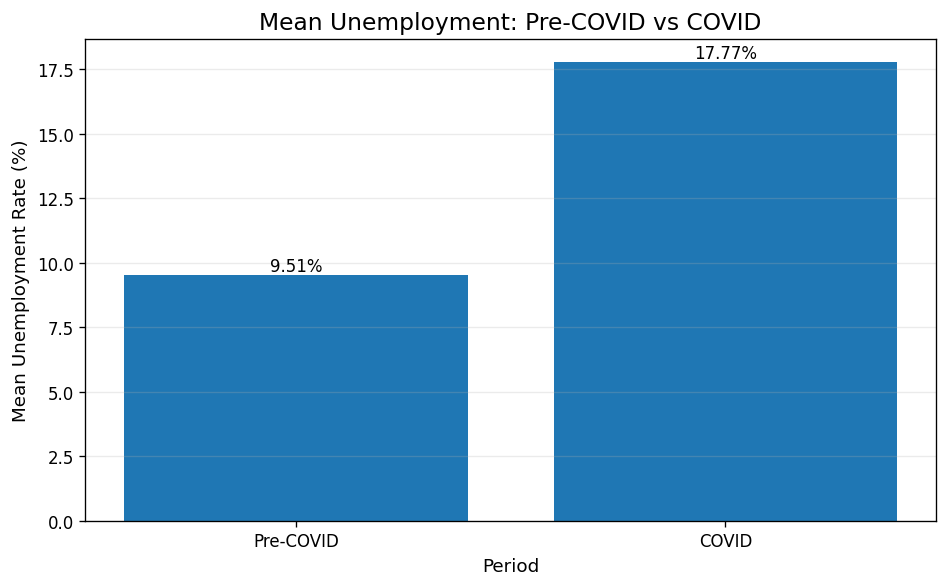

In [23]:
period_plot = (
    clean_df.groupby("Period")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(["Pre-COVID", "COVID"])
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(period_plot.index, period_plot.values)

ax.set_title("Mean Unemployment: Pre-COVID vs COVID")
ax.set_xlabel("Period")
ax.set_ylabel("Mean Unemployment Rate (%)")

for bar, value in zip(bars, period_plot.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.3 Unemployment distribution by period

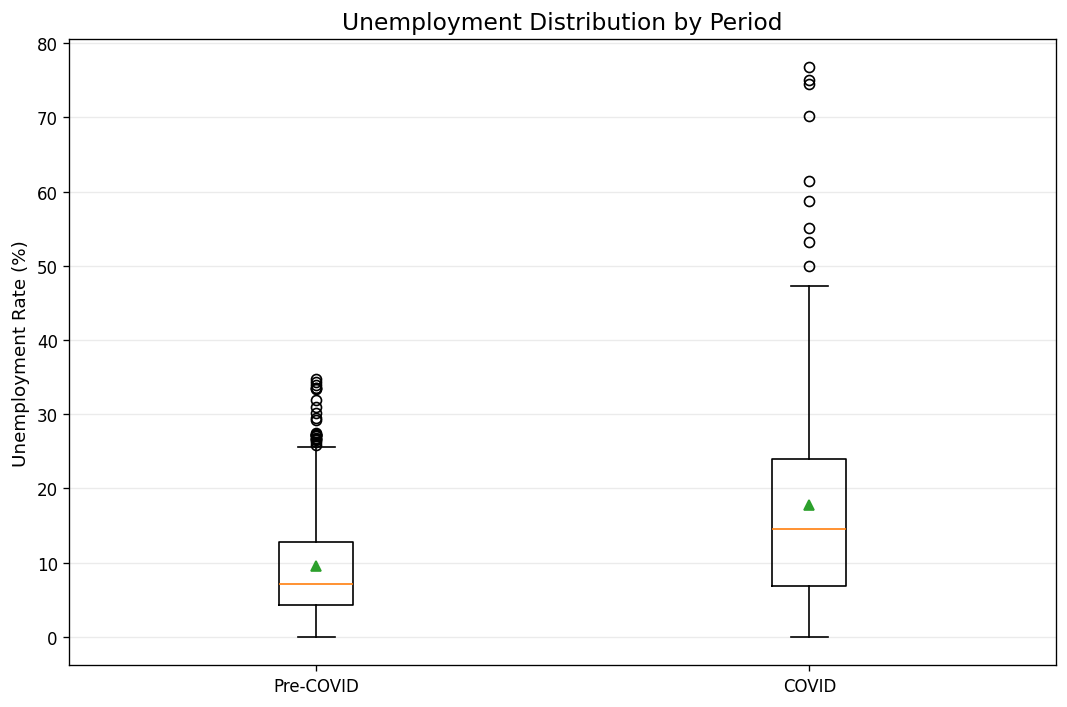

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

data = [
    clean_df.loc[
        clean_df["Period"] == "Pre-COVID",
        "Estimated Unemployment Rate (%)"
    ],
    clean_df.loc[
        clean_df["Period"] == "COVID",
        "Estimated Unemployment Rate (%)"
    ]
]

ax.boxplot(data, labels=["Pre-COVID", "COVID"], showmeans=True)
ax.set_title("Unemployment Distribution by Period")
ax.set_ylabel("Unemployment Rate (%)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.4 Rural vs Urban trend

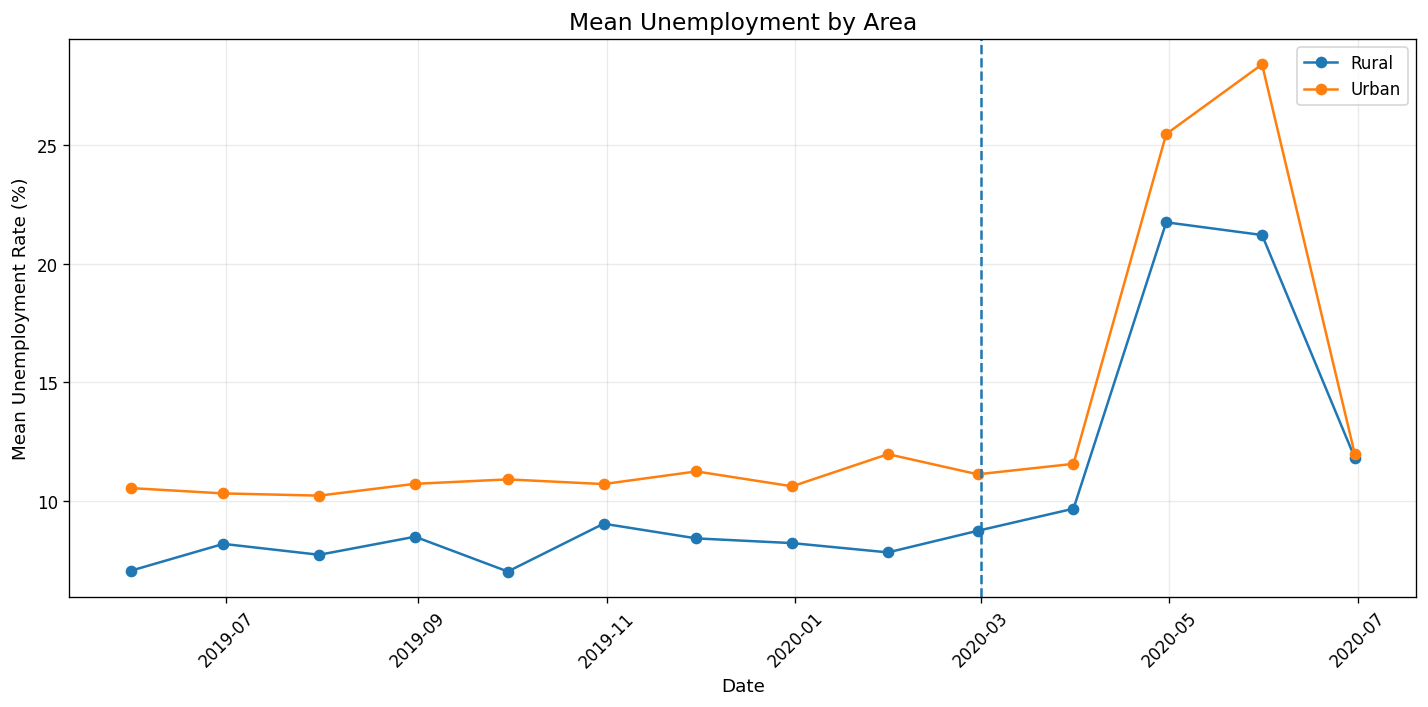

In [25]:
area_monthly = (
    clean_df.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

for area in sorted(area_monthly["Area"].unique()):
    part = area_monthly[area_monthly["Area"] == area]
    ax.plot(
        part["Date"],
        part["Estimated Unemployment Rate (%)"],
        marker="o",
        label=area
    )

ax.axvline(COVID_START, linestyle="--", linewidth=1.5)
ax.set_title("Mean Unemployment by Area")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Unemployment Rate (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Urban unemployment is higher than Rural unemployment on average in the available data, while the COVID-period distributions converge enough that the balanced-region statistical test is not significant at the 5% level.

### 9.5 Regional pre-COVID vs COVID

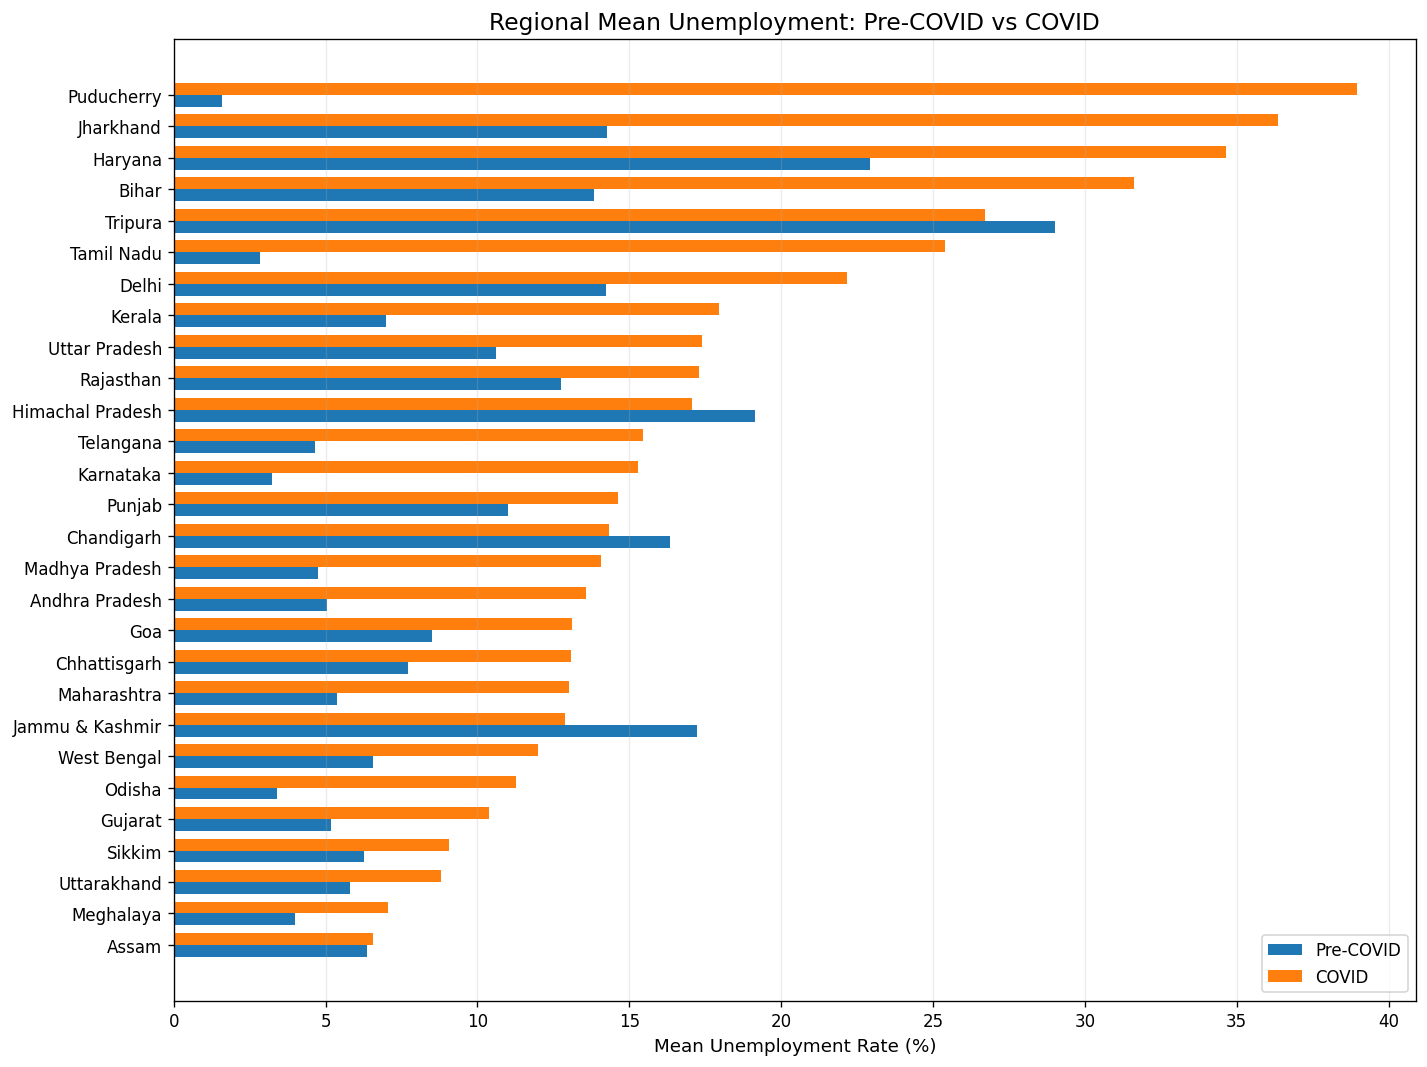

In [26]:
regional_period = (
    clean_df.groupby(["Region", "Period"])["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
)

regional_period = regional_period.dropna(subset=["Pre-COVID", "COVID"])
regional_period = regional_period.sort_values("COVID")

fig, ax = plt.subplots(figsize=(12, 9))

y = np.arange(len(regional_period))
height = 0.38

ax.barh(
    y - height/2,
    regional_period["Pre-COVID"],
    height,
    label="Pre-COVID"
)

ax.barh(
    y + height/2,
    regional_period["COVID"],
    height,
    label="COVID"
)

ax.set_yticks(y)
ax.set_yticklabels(regional_period.index)
ax.set_title("Regional Mean Unemployment: Pre-COVID vs COVID")
ax.set_xlabel("Mean Unemployment Rate (%)")
ax.legend()
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.6 Unemployment vs labour participation

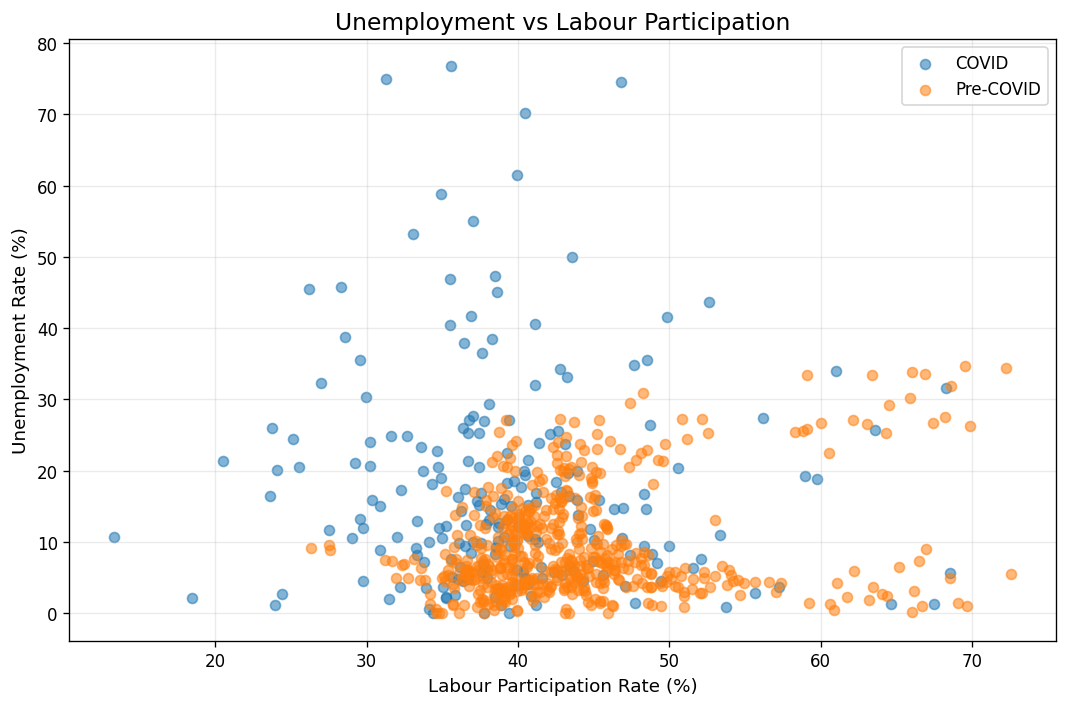

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

for period, subset in clean_df.groupby("Period"):
    ax.scatter(
        subset["Estimated Labour Participation Rate (%)"],
        subset["Estimated Unemployment Rate (%)"],
        alpha=0.55,
        label=period
    )

ax.set_title("Unemployment vs Labour Participation")
ax.set_xlabel("Labour Participation Rate (%)")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 9.7 Distributions

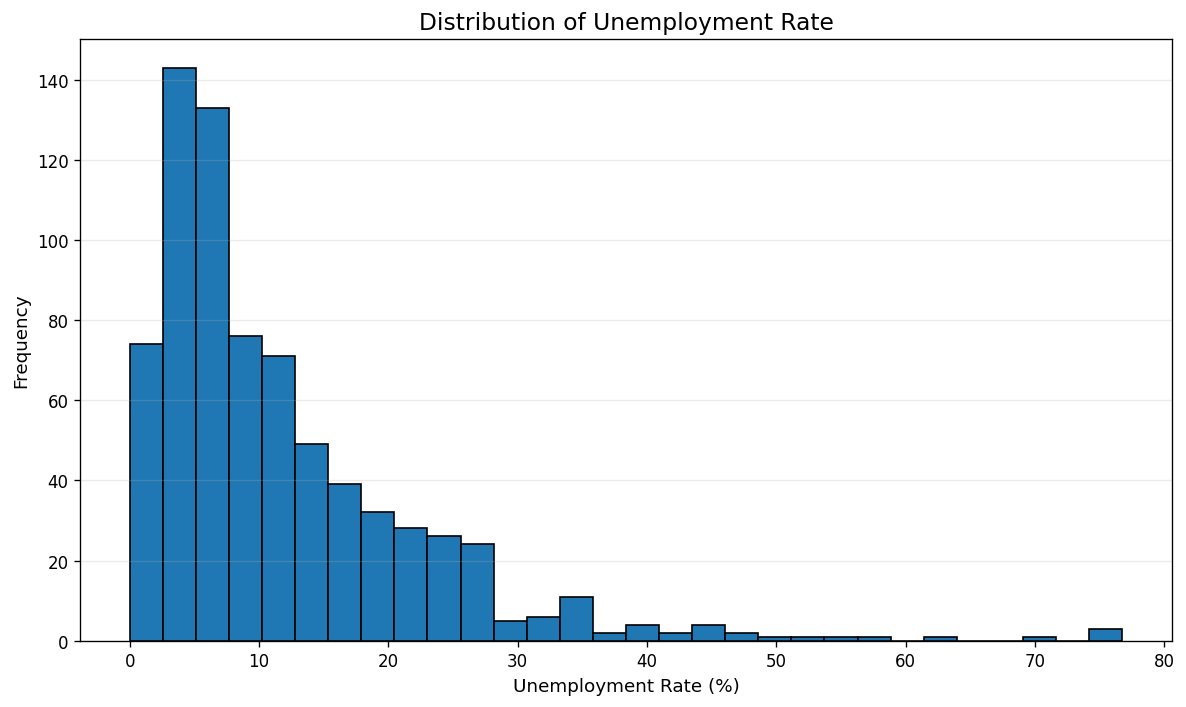

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    clean_df["Estimated Unemployment Rate (%)"],
    bins=30,
    edgecolor="black"
)
ax.set_title("Distribution of Unemployment Rate")
ax.set_xlabel("Unemployment Rate (%)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Area Analysis

In [29]:
area_period_summary = (
    clean_df.groupby(["Period", "Area"])["Estimated Unemployment Rate (%)"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(area_period_summary)

,Period,Area,count,mean,median,std
0,COVID,Rural,99,16.181313,12.500,14.154468
1,COVID,Urban,105,19.276381,15.220,15.737605
2,Pre-COVID,Rural,260,8.094808,5.790,6.737296
3,Pre-COVID,Urban,276,10.842246,7.875,7.676384


In [30]:
balanced_region_df = clean_df[
    clean_df["Region"].isin(fully_covered_regions)
].copy()

balanced_area_period = (
    balanced_region_df
    .groupby(["Period", "Area"])["Estimated Unemployment Rate (%)"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(balanced_area_period)

,Period,Area,count,mean,median,std
0,COVID,Rural,92,16.554783,12.375,14.462753
1,COVID,Urban,95,20.031579,15.730,16.229939
2,Pre-COVID,Rural,239,7.920544,5.740,6.676575
3,Pre-COVID,Urban,240,10.526458,7.590,7.735685


## 11. Regional Profiling

In [31]:
regional_profile = (
    clean_df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .agg(
        Overall_Mean="mean",
        Overall_Median="median",
        Overall_SD="std"
    )
)

pre_regional = (
    clean_df[clean_df["Period"] == "Pre-COVID"]
    .groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .rename("Pre_COVID_Mean")
)

covid_regional = (
    clean_df[clean_df["Period"] == "COVID"]
    .groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .rename("COVID_Mean")
)

regional_profile = pd.concat(
    [regional_profile, pre_regional, covid_regional],
    axis=1
)

regional_profile["Shock_Magnitude_pp"] = (
    regional_profile["COVID_Mean"]
    - regional_profile["Pre_COVID_Mean"]
)

regional_profile["Shock_%_of_Baseline"] = (
    regional_profile["Shock_Magnitude_pp"]
    / regional_profile["Pre_COVID_Mean"]
    * 100
)

regional_profile["CV_%"] = (
    regional_profile["Overall_SD"]
    / regional_profile["Overall_Mean"]
    * 100
)

display(
    regional_profile
    .sort_values("Shock_Magnitude_pp", ascending=False)
)

,Overall_Mean,Overall_Median,Overall_SD,Pre_COVID_Mean,COVID_Mean,Shock_Magnitude_pp,Shock_%_of_Baseline,CV_%
Region,,,,,,,,
Puducherry,10.215000,1.235,24.106816,1.593000,38.955000,37.362000,2345.386064,235.994283
Tamil Nadu,9.284286,2.780,14.455317,2.836500,25.403750,22.567250,795.601974,155.696595
Jharkhand,20.585000,17.285,16.674746,14.279500,36.348750,22.069250,154.551980,81.004352
Bihar,18.918214,15.010,12.634987,13.833000,31.631250,17.798250,128.665149,66.787420
Karnataka,6.676071,3.720,8.103508,3.234500,15.280000,12.045500,372.406864,121.381390
Haryana,26.283214,25.060,7.797119,22.935500,34.652500,11.717000,51.086743,29.665773
Kerala,10.123929,7.635,6.899331,6.992500,17.952500,10.960000,156.739364,68.148756
Telangana,7.737857,5.775,8.544484,4.656000,15.442500,10.786500,231.668814,110.424419
Madhya Pradesh,7.406429,4.950,7.757720,4.741000,14.070000,9.329000,196.772833,104.743058


### Regional shock visualization

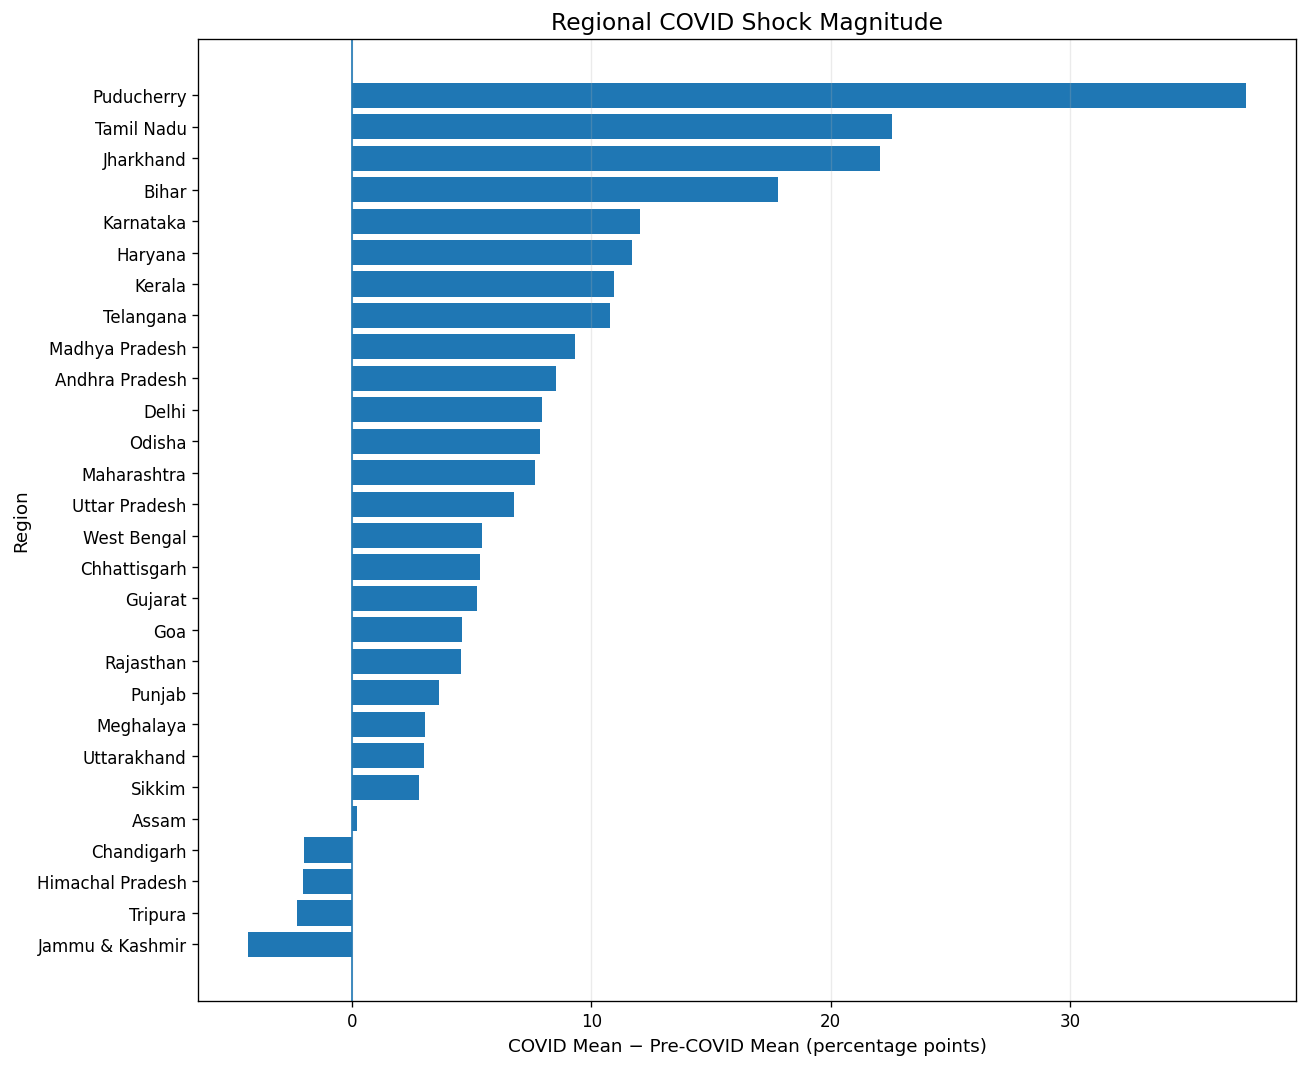

In [32]:
shock_ranking = (
    regional_profile["Shock_Magnitude_pp"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(shock_ranking.index, shock_ranking.values)

ax.axvline(0, linewidth=1)
ax.set_title("Regional COVID Shock Magnitude")
ax.set_xlabel("COVID Mean − Pre-COVID Mean (percentage points)")
ax.set_ylabel("Region")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

The largest observed positive regional shock is **Puducherry (+37.362 percentage points)**. Regional variation is substantial, so the national average should not be interpreted as a uniform regional effect.

## 12. Regional Trends and Recovery

In [33]:
trend_records = []

for region, group in clean_df.groupby("Region"):
    group = group.sort_values("Date").copy()
    x = np.arange(len(group))

    if len(group) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            x,
            group["Estimated Unemployment Rate (%)"]
        )
    else:
        slope = intercept = r_value = p_value = std_err = np.nan

    june = group.loc[
        group["Date"] == pd.Timestamp("2020-06-30"),
        "Estimated Unemployment Rate (%)"
    ]

    trend_records.append({
        "Region": region,
        "Trend_Slope_pp_per_Month": slope,
        "Trend_p_value": p_value,
        "Trend_R2": r_value**2 if pd.notna(r_value) else np.nan,
        "June_2020_Mean": june.mean() if len(june) else np.nan
    })

regional_trends = pd.DataFrame(trend_records).set_index("Region")

regional_profile = regional_profile.join(regional_trends)

regional_profile["June_vs_Pre_COVID_Gap"] = (
    regional_profile["June_2020_Mean"]
    - regional_profile["Pre_COVID_Mean"]
)

display(
    regional_profile[
        [
            "Pre_COVID_Mean",
            "COVID_Mean",
            "Shock_Magnitude_pp",
            "CV_%",
            "Trend_Slope_pp_per_Month",
            "June_2020_Mean",
            "June_vs_Pre_COVID_Gap"
        ]
    ].sort_values("Shock_Magnitude_pp", ascending=False)
)

,Pre_COVID_Mean,COVID_Mean,Shock_Magnitude_pp,CV_%,Trend_Slope_pp_per_Month,June_2020_Mean,June_vs_Pre_COVID_Gap
Region,,,,,,,
Puducherry,1.593000,38.955000,37.362000,235.994283,1.632297,4.550,2.957000
Tamil Nadu,2.836500,25.403750,22.567250,155.696595,1.014570,13.495,10.658500
Jharkhand,14.279500,36.348750,22.069250,81.004352,1.057614,20.455,6.175500
Bihar,13.833000,31.631250,17.798250,66.787420,0.770348,16.470,2.637000
Karnataka,3.234500,15.280000,12.045500,121.381390,0.496954,8.520,5.285500
Haryana,22.935500,34.652500,11.717000,29.665773,0.604546,32.490,9.554500
Kerala,6.992500,17.952500,10.960000,68.148756,0.518623,19.915,12.922500
Telangana,4.656000,15.442500,10.786500,110.424419,0.605052,13.110,8.454000
Madhya Pradesh,4.741000,14.070000,9.329000,104.743058,0.440930,9.590,4.849000


## 13. Correlation Analysis

In [34]:
correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Labour Participation Rate (%)",
    "Estimated Employed"
]

pearson_corr = clean_df[correlation_columns].corr(method="pearson")
spearman_corr = clean_df[correlation_columns].corr(method="spearman")

print("Pearson correlation:")
display(pearson_corr)

print("Spearman correlation:")
display(spearman_corr)

Pearson correlation:


,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
Estimated Unemployment Rate (%),1.000000,0.002558,-0.222876
Estimated Labour Participation Rate (%),0.002558,1.000000,0.011300
Estimated Employed,-0.222876,0.011300,1.000000


Spearman correlation:


,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
Estimated Unemployment Rate (%),1.000000,-0.023567,-0.216593
Estimated Labour Participation Rate (%),-0.023567,1.000000,0.049444
Estimated Employed,-0.216593,0.049444,1.000000


In [35]:
def correlation_test(x, y):
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_rho, spearman_p = stats.spearmanr(x, y)
    return {
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    }

corr_records = []

for period in ["All", "Pre-COVID", "COVID"]:
    subset = (
        clean_df if period == "All"
        else clean_df[clean_df["Period"] == period]
    )

    for target in [
        "Estimated Labour Participation Rate (%)",
        "Estimated Employed"
    ]:
        result = correlation_test(
            subset["Estimated Unemployment Rate (%)"],
            subset[target]
        )

        corr_records.append({
            "Period": period,
            "Relationship": f"Unemployment vs {target}",
            **result
        })

correlation_tests = pd.DataFrame(corr_records)
display(correlation_tests)

,Period,Relationship,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All,Unemployment vs Estimated Labour Participation...,0.002558,9.446182e-01,-0.023567,5.221025e-01
1,All,Unemployment vs Estimated Employed,-0.222876,8.792864e-10,-0.216593,2.635870e-09
2,Pre-COVID,Unemployment vs Estimated Labour Participation...,0.243159,1.182758e-08,0.098536,2.251905e-02
3,Pre-COVID,Unemployment vs Estimated Employed,-0.272234,1.460931e-10,-0.242824,1.240347e-08
4,COVID,Unemployment vs Estimated Labour Participation...,-0.058458,4.062438e-01,-0.076348,2.777649e-01
5,COVID,Unemployment vs Estimated Employed,-0.184909,8.104757e-03,-0.146724,3.625089e-02


## 14. Rural vs Urban Statistical Tests

The Mann-Whitney U test compares the distributions without requiring normality.

In [36]:
def rank_biserial_from_u(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

mw_records = []

for period in ["Pre-COVID", "COVID"]:
    subset = balanced_region_df[
        balanced_region_df["Period"] == period
    ]

    rural = subset.loc[
        subset["Area"].str.lower() == "rural",
        "Estimated Unemployment Rate (%)"
    ].dropna()

    urban = subset.loc[
        subset["Area"].str.lower() == "urban",
        "Estimated Unemployment Rate (%)"
    ].dropna()

    u_stat, p_value = stats.mannwhitneyu(
        rural,
        urban,
        alternative="two-sided"
    )

    mw_records.append({
        "Period": period,
        "Rural_N": len(rural),
        "Urban_N": len(urban),
        "Rural_Median": rural.median(),
        "Urban_Median": urban.median(),
        "U": u_stat,
        "p_value": p_value,
        "Rank_Biserial": rank_biserial_from_u(
            u_stat, len(rural), len(urban)
        )
    })

mann_whitney_results = pd.DataFrame(mw_records)
display(mann_whitney_results)

,Period,Rural_N,Urban_N,Rural_Median,Urban_Median,U,p_value,Rank_Biserial
0,Pre-COVID,239,240,5.740,7.59,21897.5,0.000008,0.236489
1,COVID,92,95,12.375,15.73,3707.0,0.073394,0.151716


### Interpretation

- Before COVID, the balanced-region Rural vs Urban comparison is statistically significant.
- During COVID, the corresponding comparison is not statistically significant at the 5% level.
- Effect sizes are small in both periods.

These tests describe distributional differences; they do not establish causes.

## 15. Regional Kruskal-Wallis Tests

In [37]:
kw_records = []

for period in ["Pre-COVID", "COVID"]:
    subset = balanced_region_df[
        balanced_region_df["Period"] == period
    ]

    groups = [
        group["Estimated Unemployment Rate (%)"].dropna().values
        for _, group in subset.groupby("Region")
    ]

    h_stat, p_value = stats.kruskal(*groups)

    n = sum(len(g) for g in groups)
    k = len(groups)

    epsilon_sq = (h_stat - k + 1) / (n - k)

    kw_records.append({
        "Period": period,
        "H": h_stat,
        "p_value": p_value,
        "epsilon_squared": epsilon_sq,
        "regions": k,
        "observations": n
    })

kruskal_results = pd.DataFrame(kw_records)
display(kruskal_results)

,Period,H,p_value,epsilon_squared,regions,observations
0,Pre-COVID,374.642205,2.877543e-65,0.772840,24,479
1,COVID,55.992611,1.418785e-04,0.202409,24,187


The Kruskal-Wallis results support statistically significant regional heterogeneity in both periods. The estimated epsilon-squared effect sizes are large, especially before COVID.

## 16. Regional Clustering

Clustering is performed on regional-level features:

- Pre-COVID mean unemployment
- COVID mean unemployment
- Shock magnitude
- Coefficient of variation
- Trend slope
- Pre-COVID mean participation
- COVID mean participation

In [38]:
participation_profile = (
    clean_df.groupby(["Region", "Period"])
    ["Estimated Labour Participation Rate (%)"]
    .mean()
    .unstack()
    .rename(columns={
        "Pre-COVID": "Pre_COVID_Mean_Participation",
        "COVID": "COVID_Mean_Participation"
    })
)

cluster_features = regional_profile.join(participation_profile)

feature_cols = [
    "Pre_COVID_Mean",
    "COVID_Mean",
    "Shock_Magnitude_pp",
    "CV_%",
    "Trend_Slope_pp_per_Month",
    "Pre_COVID_Mean_Participation",
    "COVID_Mean_Participation"
]

cluster_features = cluster_features[feature_cols].dropna()

display(cluster_features.head())
print("Regions used:", len(cluster_features))

,Pre_COVID_Mean,COVID_Mean,Shock_Magnitude_pp,CV_%,Trend_Slope_pp_per_Month,Pre_COVID_Mean_Participation,COVID_Mean_Participation
Region,,,,,,,
Andhra Pradesh,5.037500,13.576250,8.53875,91.640263,0.393388,40.028000,37.745000
Assam,6.372632,6.578571,0.20594,46.798104,-0.011320,45.994737,41.811429
Bihar,13.833000,31.631250,17.79825,66.787420,0.770348,38.484000,37.328750
Chandigarh,16.325000,14.325000,-2.00000,34.444315,-0.181958,40.156000,35.240000
Chhattisgarh,7.706500,13.075000,5.36850,62.879621,0.260561,44.948500,37.466250


Regions used: 28


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

scaled_df = pd.DataFrame(
    X_scaled,
    index=cluster_features.index,
    columns=feature_cols
)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "Component": np.arange(1, len(feature_cols) + 1),
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance)

,Component,Explained_Variance_Ratio,Cumulative
0,1,5.062381e-01,0.506238
1,2,2.509880e-01,0.757226
2,3,2.027662e-01,0.959992
3,4,2.354029e-02,0.983533
4,5,1.514618e-02,0.998679
5,6,1.321216e-03,1.000000
6,7,4.607964e-33,1.000000


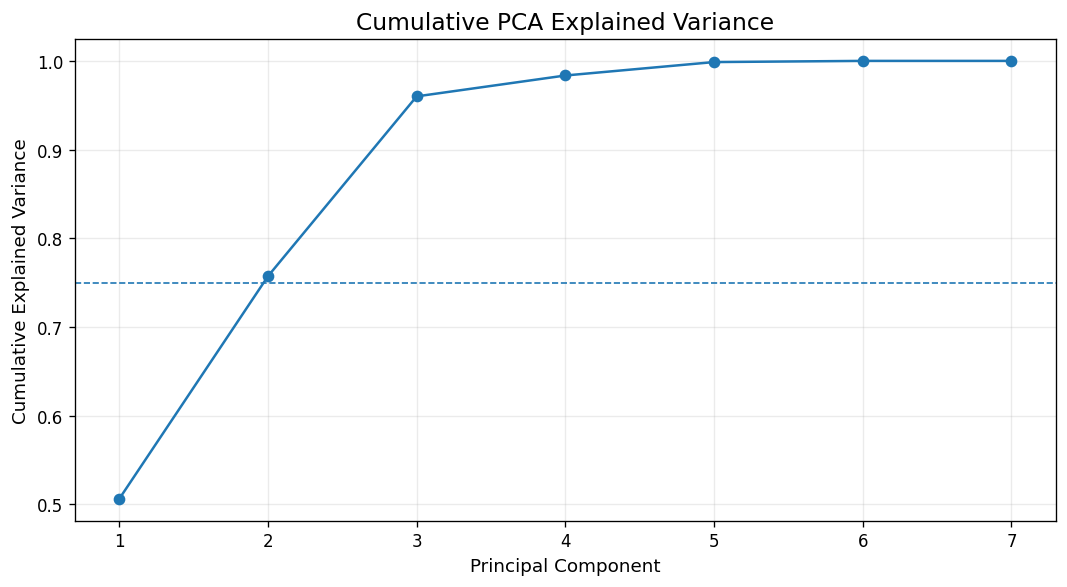

PC1 + PC2 explained variance: 75.72%


In [40]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    explained_variance["Component"],
    explained_variance["Cumulative"],
    marker="o"
)

ax.axhline(0.75, linestyle="--", linewidth=1)
ax.set_title("Cumulative PCA Explained Variance")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(
    "PC1 + PC2 explained variance:",
    f"{explained_variance.loc[1, 'Cumulative']:.2%}"
)

### Select K using silhouette and elbow diagnostics

In [41]:
k_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    labels = model.fit_predict(X_scaled)

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

k_evaluation = pd.DataFrame(k_results)
display(k_evaluation)

,k,inertia,silhouette
0,2,133.516371,0.417908
1,3,96.850855,0.409079
2,4,78.040237,0.381213
3,5,55.556015,0.269779
4,6,42.426758,0.270183
5,7,34.296207,0.253151
6,8,27.372294,0.248631


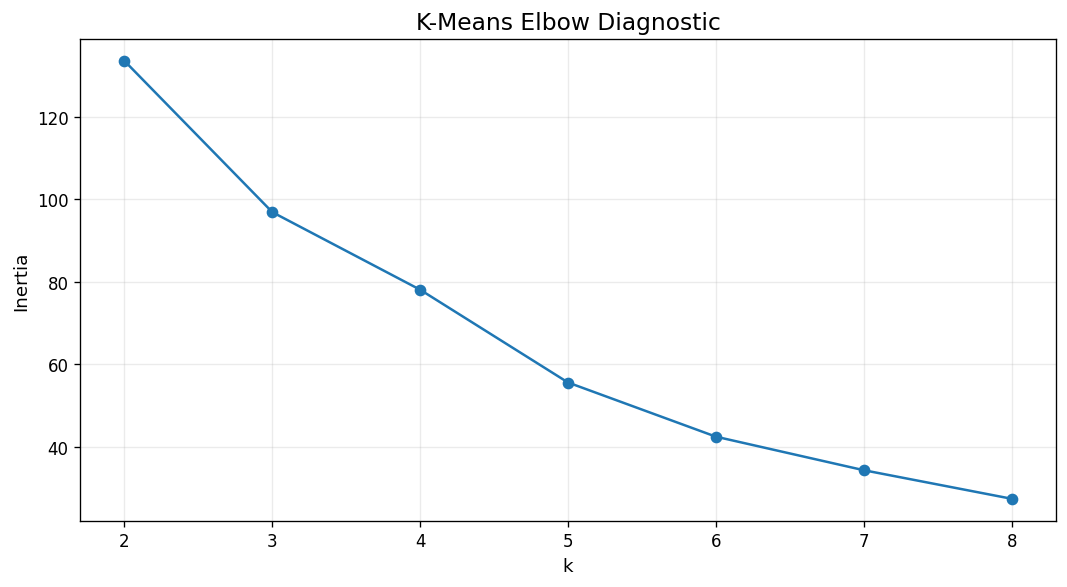

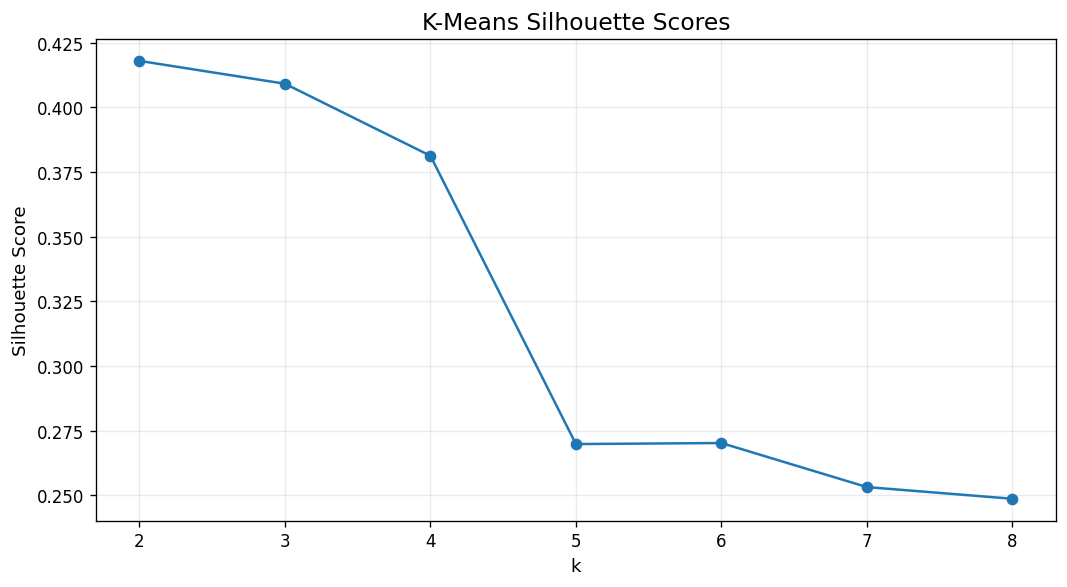

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_evaluation["k"], k_evaluation["inertia"], marker="o")
ax.set_title("K-Means Elbow Diagnostic")
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_evaluation["k"], k_evaluation["silhouette"], marker="o")
ax.set_title("K-Means Silhouette Scores")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [43]:
selected_k = 2

kmeans = KMeans(
    n_clusters=selected_k,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_assignments = pd.DataFrame({
    "Region": cluster_features.index,
    "Cluster": cluster_labels
}).set_index("Region")

cluster_assignments["Cluster"].value_counts().sort_index()

Cluster
0    24
1     4
Name: count, dtype: int64

In [44]:
cluster_profile = (
    cluster_features.join(cluster_assignments)
    .groupby("Cluster")[feature_cols]
    .mean()
)

display(cluster_profile)

print("Cluster membership:")
display(
    cluster_assignments
    .reset_index()
    .sort_values(["Cluster", "Region"])
)

,Pre_COVID_Mean,COVID_Mean,Shock_Magnitude_pp,CV_%,Trend_Slope_pp_per_Month,Pre_COVID_Mean_Participation,COVID_Mean_Participation
Cluster,,,,,,,
0,9.877267,14.910509,5.033243,64.100185,0.243405,44.320182,39.717736
1,8.135500,33.084688,24.949188,134.870663,1.118707,41.286000,36.291458


Cluster membership:


,Region,Cluster
0,Andhra Pradesh,0
1,Assam,0
3,Chandigarh,0
4,Chhattisgarh,0
5,Delhi,0
6,Goa,0
7,Gujarat,0
8,Haryana,0
9,Himachal Pradesh,0
10,Jammu & Kashmir,0


### Clustering interpretation

The selected two-cluster solution separates regions primarily according to their baseline/shock/volatility structure.

One cluster contains only four regions:

**Bihar, Jharkhand, Puducherry, Tamil Nadu**

Because the full clustering sample contains only 28 regions and one cluster has four members, the segmentation is descriptive and should not be treated as a stable population taxonomy.

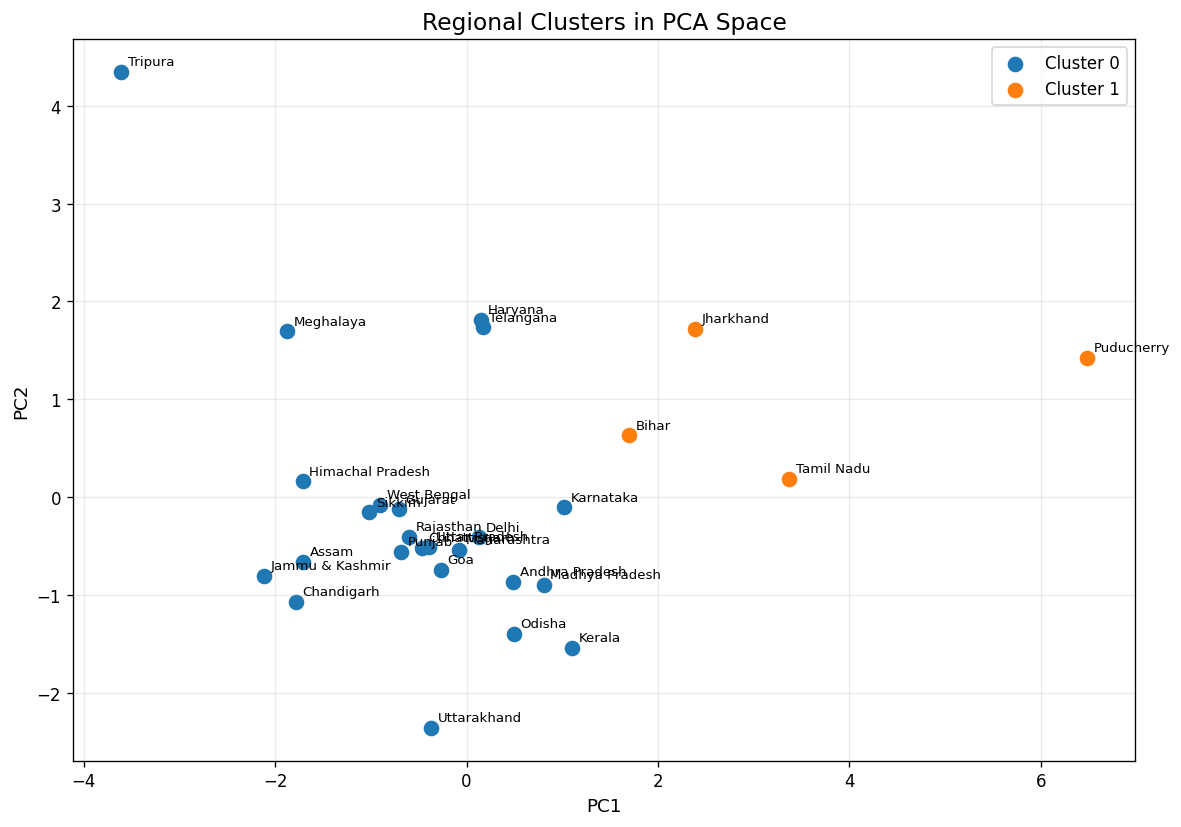

In [45]:
pca_2d = pd.DataFrame(
    pca_scores[:, :2],
    columns=["PC1", "PC2"],
    index=cluster_features.index
).join(cluster_assignments)

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, subset in pca_2d.groupby("Cluster"):
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=70,
        label=f"Cluster {cluster_id}"
    )

    for region, row in subset.iterrows():
        ax.annotate(
            region,
            (row["PC1"], row["PC2"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.set_title("Regional Clusters in PCA Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 17. Anomaly Detection

Two methods are applied separately to each Region-Area time series:

1. **IQR rule:** observations below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.
2. **Trailing rolling z-score:** standardized against the previous three observations, shifted so the current observation does not define its own baseline.

Anomaly labels are then interpreted using the project period context.

In [46]:
anomaly_parts = []

for (region, area), group in clean_df.groupby(["Region", "Area"]):
    group = group.sort_values("Date").copy()

    values = group["Estimated Unemployment Rate (%)"]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    group["IQR_Lower"] = lower
    group["IQR_Upper"] = upper
    group["IQR_Anomaly"] = (
        (values < lower) | (values > upper)
    )

    rolling_mean = values.shift(1).rolling(
        window=3,
        min_periods=2
    ).mean()

    rolling_std = values.shift(1).rolling(
        window=3,
        min_periods=2
    ).std()

    group["Rolling_Z"] = (
        values - rolling_mean
    ) / rolling_std.replace(0, np.nan)

    group["Rolling_Z_Anomaly"] = (
        group["Rolling_Z"].abs() >= 3
    )

    group["Any_Anomaly"] = (
        group["IQR_Anomaly"] |
        group["Rolling_Z_Anomaly"]
    )

    anomaly_parts.append(group)

anomaly_df = pd.concat(anomaly_parts, ignore_index=True)

print("IQR flags:", int(anomaly_df["IQR_Anomaly"].sum()))
print("Rolling z-score flags:", int(anomaly_df["Rolling_Z_Anomaly"].sum()))
print("Unique flagged observations:", int(anomaly_df["Any_Anomaly"].sum()))

IQR flags: 93
Rolling z-score flags: 127
Unique flagged observations: 173


In [47]:
def classify_anomaly(row):
    if not row["Any_Anomaly"]:
        return "Not flagged"

    value = row["Estimated Unemployment Rate (%)"]

    if value < 0 or value > 100:
        return "Data-quality anomaly"

    if row["Date"] in [
        pd.Timestamp("2020-04-30"),
        pd.Timestamp("2020-05-31")
    ]:
        return "Legitimate COVID extreme event"

    if (
        pd.Timestamp("2020-03-01")
        <= row["Date"]
        <= pd.Timestamp("2020-06-30")
    ):
        return "COVID-period noteworthy anomaly"

    return "Noteworthy / unexplained"

anomaly_df["Anomaly_Category"] = anomaly_df.apply(
    classify_anomaly,
    axis=1
)

anomaly_summary = (
    anomaly_df[anomaly_df["Any_Anomaly"]]
    ["Anomaly_Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

display(anomaly_summary)

,Category,Count
0,Legitimate COVID extreme event,79
1,Noteworthy / unexplained,71
2,COVID-period noteworthy anomaly,23


**Interpretation:** The anomaly flags are heavily concentrated around the COVID shock. A "noteworthy / unexplained" observation is not automatically erroneous; it simply lacks enough contextual information in this dataset for attribution.

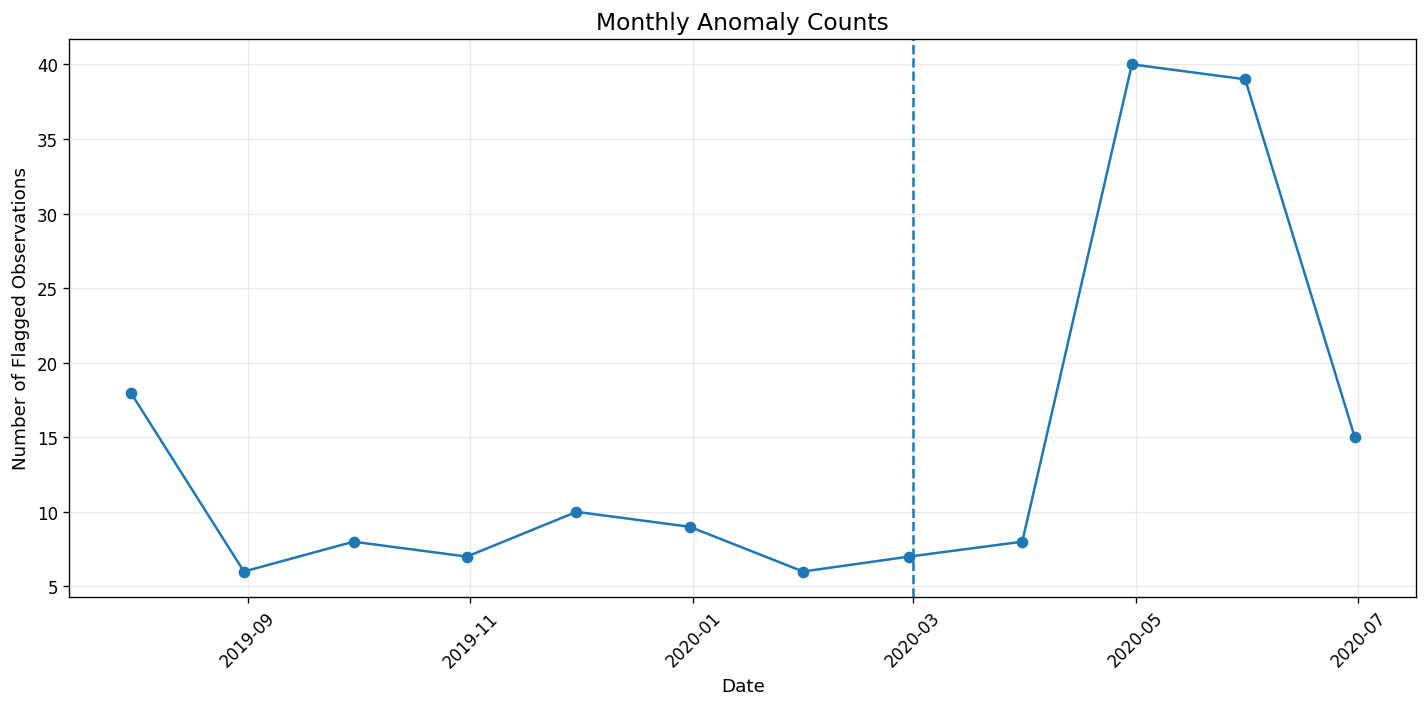

In [48]:
monthly_anomalies = (
    anomaly_df[anomaly_df["Any_Anomaly"]]
    .groupby("Date")
    .size()
    .reset_index(name="Anomaly_Count")
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    monthly_anomalies["Date"],
    monthly_anomalies["Anomaly_Count"],
    marker="o"
)
ax.axvline(COVID_START, linestyle="--", linewidth=1.5)
ax.set_title("Monthly Anomaly Counts")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Flagged Observations")
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Time-Series Diagnostics

The national series contains only **14 monthly observations**. Therefore, stationarity, ACF/PACF, and forecasting diagnostics are interpreted cautiously.

In [49]:
national_series = (
    clean_df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

print("Number of observations:", len(national_series))
display(national_series.to_frame("Mean_Unemployment"))

Number of observations: 14


,Mean_Unemployment
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731
2019-10-31,9.900909
2019-11-30,9.868364
2019-12-31,9.497358
2020-01-31,9.950755


In [50]:
adf_result = adfuller(national_series, autolag="AIC")

kpss_result = kpss(
    national_series,
    regression="c",
    nlags="auto"
)

stationarity_results = pd.DataFrame([
    {
        "Test": "ADF",
        "Series": "Level",
        "Statistic": adf_result[0],
        "p_value": adf_result[1]
    },
    {
        "Test": "KPSS",
        "Series": "Level",
        "Statistic": kpss_result[0],
        "p_value": kpss_result[1]
    }
])

display(stationarity_results)

,Test,Series,Statistic,p_value
0,ADF,Level,2.361709,0.998991
1,KPSS,Level,0.403519,0.075638


In [51]:
first_diff = national_series.diff().dropna()

adf_diff = adfuller(first_diff, autolag="AIC")
kpss_diff = kpss(
    first_diff,
    regression="c",
    nlags="auto"
)

difference_stationarity = pd.DataFrame([
    {
        "Test": "ADF",
        "Series": "First Difference",
        "Statistic": adf_diff[0],
        "p_value": adf_diff[1]
    },
    {
        "Test": "KPSS",
        "Series": "First Difference",
        "Statistic": kpss_diff[0],
        "p_value": kpss_diff[1]
    }
])

display(difference_stationarity)

,Test,Series,Statistic,p_value
0,ADF,First Difference,-2.552746,0.103162
1,KPSS,First Difference,0.074195,0.100000


In [52]:
acf_values = acf(national_series, nlags=5, fft=False)
pacf_values = pacf(national_series, nlags=5, method="ywm")

acf_table = pd.DataFrame({
    "Lag": range(len(acf_values)),
    "ACF": acf_values
})

pacf_table = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "PACF": pacf_values
})

display(acf_table)
display(pacf_table)

,Lag,ACF
0,0,1.000000
1,1,0.524042
2,2,0.028121
3,3,-0.017344
4,4,-0.046286
5,5,-0.067537


,Lag,PACF
0,0,1.000000
1,1,0.524042
2,2,-0.339819
3,3,0.219744
4,4,-0.219564
5,5,0.110607


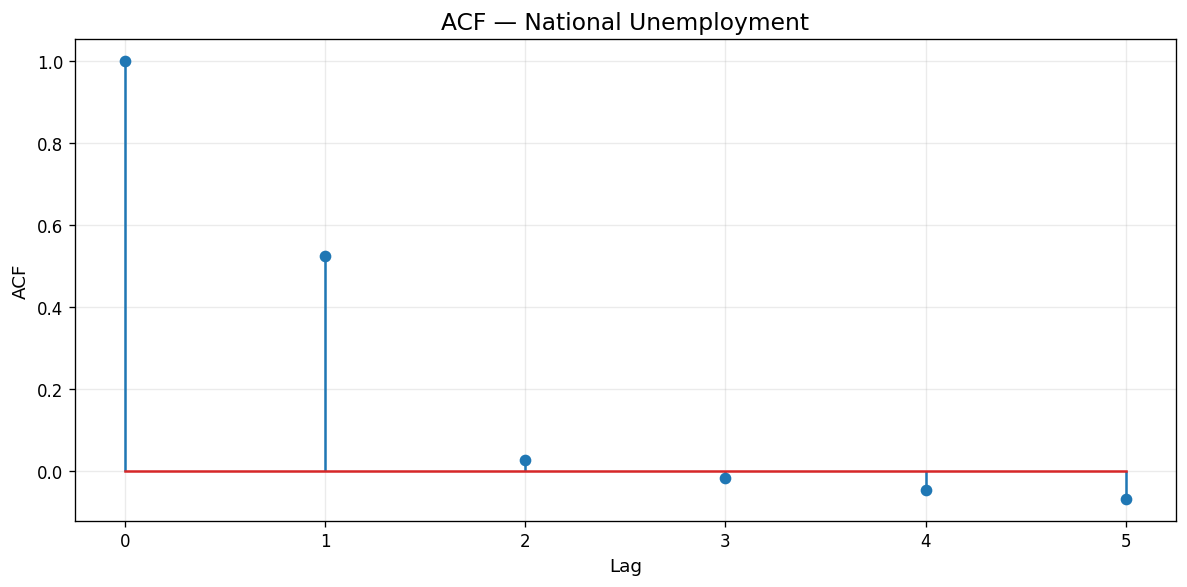

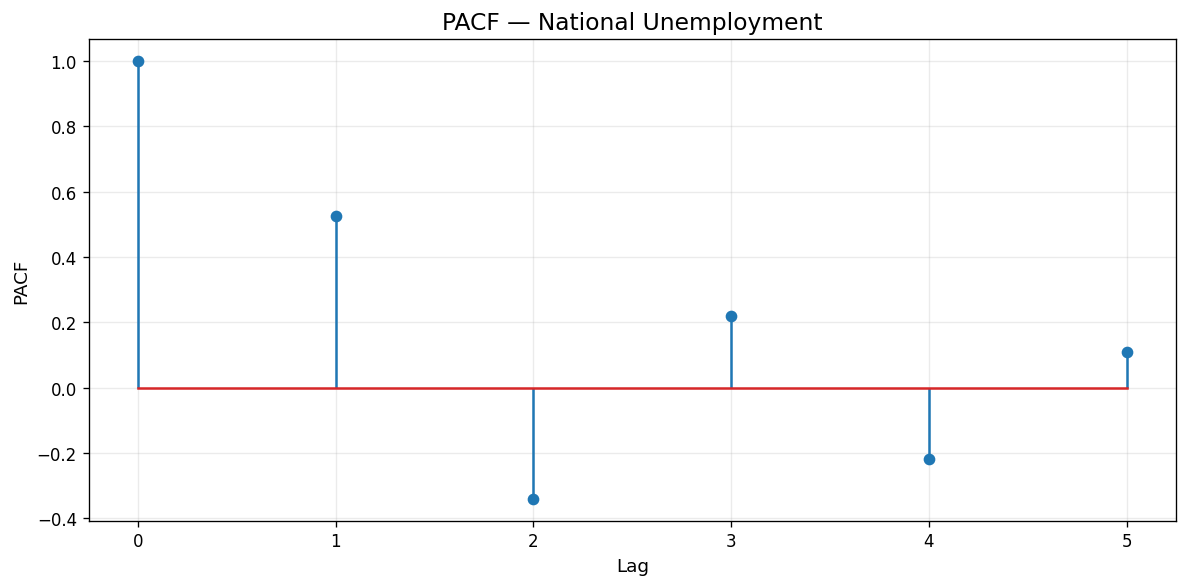

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.stem(acf_table["Lag"], acf_table["ACF"])
ax.set_title("ACF — National Unemployment")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.stem(pacf_table["Lag"], pacf_table["PACF"])
ax.set_title("PACF — National Unemployment")
ax.set_xlabel("Lag")
ax.set_ylabel("PACF")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The level-series tests are not fully concordant, and the short sample contains a major structural shock. There is no reliable basis for claiming annual seasonality from only 14 months.

## 19. Scoped Forecasting

Forecasting is deliberately limited to rolling-origin one-step-ahead evaluation.

Models:

- Naive
- Drift
- Simple Exponential Smoothing
- Holt Linear
- AR(1)
- AR(2)
- ARIMA(1,1,0)

The objective is benchmark comparison, not long-horizon prediction.

In [54]:
def forecast_one(model_name, train):
    if model_name == "Naive":
        return float(train.iloc[-1])

    if model_name == "Drift":
        if len(train) < 2:
            return float(train.iloc[-1])
        slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
        return float(train.iloc[-1] + slope)

    if model_name == "SES":
        model = SimpleExpSmoothing(train).fit(
            optimized=True
        )
        return float(model.forecast(1).iloc[0])

    if model_name == "Holt":
        model = Holt(train).fit(
            optimized=True
        )
        return float(model.forecast(1).iloc[0])

    if model_name == "AR1":
        model = AutoReg(train, lags=1, trend="c", old_names=False).fit()
        return float(model.predict(
            start=len(train),
            end=len(train)
        ).iloc[0])

    if model_name == "AR2":
        if len(train) < 5:
            raise ValueError("AR2 requires more training observations.")
        model = AutoReg(train, lags=2, trend="c", old_names=False).fit()
        return float(model.predict(
            start=len(train),
            end=len(train)
        ).iloc[0])

    if model_name == "ARIMA":
        model = ARIMA(train, order=(1, 1, 0)).fit()
        return float(model.forecast(1).iloc[0])

    raise ValueError(f"Unknown model: {model_name}")


models = [
    "Naive",
    "Drift",
    "SES",
    "Holt",
    "AR1",
    "AR2",
    "ARIMA"
]

initial_train = 8
forecast_records = []

for i in range(initial_train, len(national_series)):
    train = national_series.iloc[:i]
    actual = float(national_series.iloc[i])
    test_date = national_series.index[i]

    for model_name in models:
        try:
            prediction = forecast_one(model_name, train)
        except Exception:
            prediction = np.nan

        forecast_records.append({
            "Date": test_date,
            "Model": model_name,
            "Actual": actual,
            "Forecast": prediction,
            "Error": actual - prediction
        })

forecast_values = pd.DataFrame(forecast_records)
forecast_values["Absolute_Error"] = (
    forecast_values["Error"].abs()
)
forecast_values["Squared_Error"] = (
    forecast_values["Error"] ** 2
)

forecast_metrics = (
    forecast_values.dropna()
    .groupby("Model")
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Squared_Error", lambda x: np.sqrt(x.mean())),
        Mean_Error=("Error", "mean"),
        Test_Points=("Error", "size")
    )
    .sort_values("MAE")
    .reset_index()
)

display(forecast_metrics)

,Model,MAE,RMSE,Mean_Error,Test_Points
0,Drift,4.711985,7.831018,-0.132838,6
1,Naive,4.724938,7.505592,0.401040,6
2,SES,4.804297,7.600595,0.480399,6
3,ARIMA,5.306632,7.839955,-0.414192,6
4,Holt,6.288155,8.742450,1.821232,6
5,AR1,15.702430,27.323631,-10.627507,6
6,AR2,24.667780,38.933951,-19.825733,6


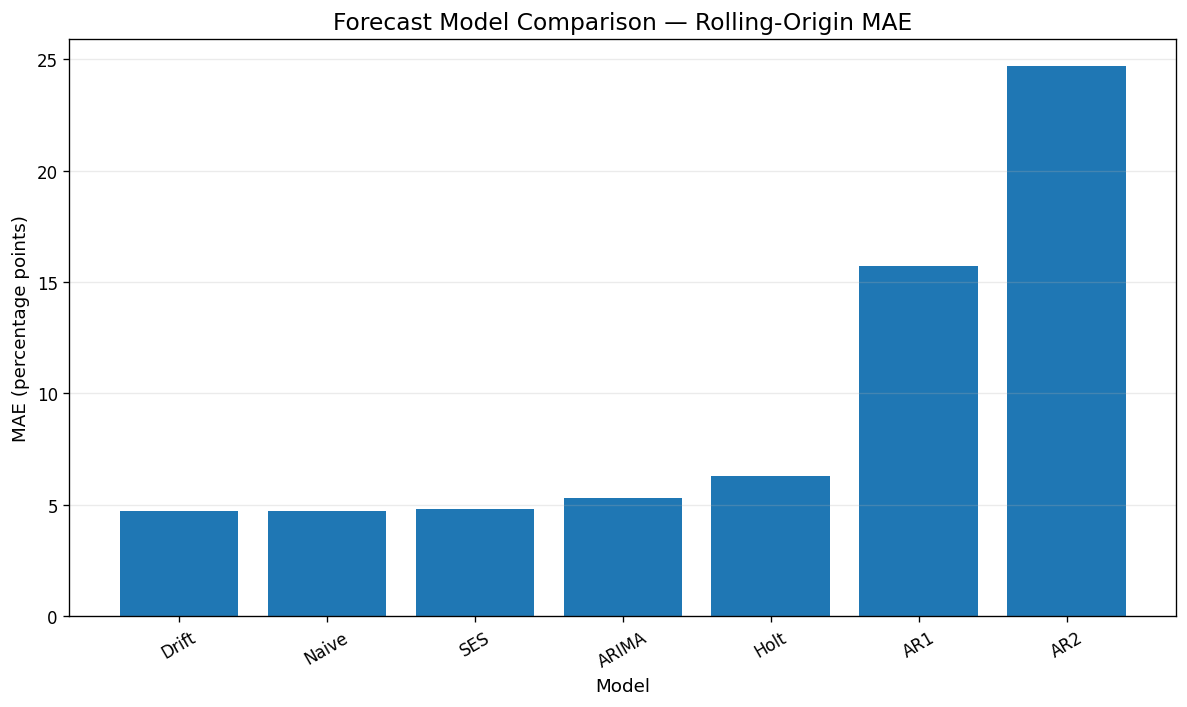

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    forecast_metrics["Model"],
    forecast_metrics["MAE"]
)

ax.set_title("Forecast Model Comparison — Rolling-Origin MAE")
ax.set_xlabel("Model")
ax.set_ylabel("MAE (percentage points)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [56]:
covid_forecast_metrics = (
    forecast_values[
        forecast_values["Date"] >= COVID_START
    ]
    .dropna()
    .groupby("Model")
    .agg(
        COVID_MAE=("Absolute_Error", "mean"),
        COVID_RMSE=("Squared_Error", lambda x: np.sqrt(x.mean())),
        Test_Points=("Error", "size")
    )
    .sort_values("COVID_MAE")
    .reset_index()
)

display(covid_forecast_metrics)

,Model,COVID_MAE,COVID_RMSE,Test_Points
0,Drift,6.946732,9.589079,4
1,Naive,6.970568,9.189637,4
2,SES,7.073065,9.306699,4
3,ARIMA,7.824888,9.599950,4
4,Holt,9.381394,10.706901,4
5,AR1,23.336160,33.463050,4
6,AR2,36.857039,47.683671,4


### Forecasting conclusion

The best model in this rolling-origin benchmark is reported by the MAE table above. The test set is very small, and the COVID period represents a structural shock. Therefore, no long-horizon forecasting model is claimed to be reliable from this dataset alone.

# 20. Key Findings

### Observed facts

- The cleaned dataset contains **740 observations**, **28 regions**, **2 areas**, and **14 monthly dates**.
- There are **20 fully covered regions** and **8 incomplete regions**.
- Mean unemployment increased substantially from the Pre-COVID period to the COVID period.
- The national monthly mean reached its maximum in **May 2020**.
- Regional shock magnitudes vary substantially.
- The balanced-region Rural vs Urban comparison is statistically significant before COVID and not significant during COVID at the 5% level.
- Kruskal-Wallis testing indicates significant regional heterogeneity in both periods.
- Overall unemployment vs participation has a very weak Spearman relationship.
- Anomaly flags concentrate strongly around the COVID shock.
- No hard out-of-range data-quality anomalies were detected.
- The time series is too short for strong seasonal or long-horizon forecasting claims.
- K-Means produced a two-cluster descriptive segmentation, with one cluster containing four regions.

### Analytical interpretations

- The national average alone does not describe the regional labour-market response.
- The COVID period should be treated as a structural shock rather than a normal continuation of the pre-COVID process.
- Rural/Urban differences appear to be period-dependent in the available sample.
- The forecasting section is most useful as a methodological benchmark rather than a production forecasting system.

# 21. Final Conclusion

This project provides a complete regional diagnostic of unemployment in India from May 2019 through June 2020.

The analysis shows a large national unemployment shock during the COVID period, accompanied by substantial regional heterogeneity. Statistical testing confirms that regional distributions differ meaningfully, while Rural/Urban differences vary by period.

The anomaly analysis identifies the April–May 2020 observations as a major concentration of legitimate COVID-period extremes rather than simply treating them as errors.

The time-series and forecasting sections are intentionally conservative. With only 14 monthly observations and a major structural shock, the data do not support strong long-horizon forecasting or reliable seasonal modeling.

### Main limitations

1. Short 14-month time series.
2. Major COVID structural break.
3. Eight regions have incomplete coverage.
4. Only 28 regions are available for clustering.
5. One cluster contains only four regions.
6. Observational data cannot establish causal mechanisms.
7. Forecast backtesting contains only a small number of test points.

### Future improvements

With a longer and more complete dataset, future work could include:

- Multi-year seasonal analysis.
- More robust time-series models.
- Longer rolling-origin validation.
- Panel-data methods.
- Richer demographic or economic covariates.
- External policy and mobility indicators.
- More robust causal designs where appropriate.

**Final analytical message:**  
**India experienced a substantial unemployment shock during COVID-19, but the magnitude and trajectory were highly heterogeneous across regions. The strongest conclusions from this dataset concern descriptive shock measurement, regional differences, statistical evidence, and transparent limitations—not long-term prediction or causation.**

# 22. Reproducibility Checklist

In [57]:
reproducibility_checks = {
    "Dataset exists": DATA_PATH.exists(),
    "No missing values": clean_df.isna().sum().sum() == 0,
    "No duplicate full rows": clean_df.duplicated().sum() == 0,
    "No duplicate Region-Date-Area": clean_df.duplicated(
        ["Region", "Date", "Area"]
    ).sum() == 0,
    "Valid unemployment range": (
        clean_df["Estimated Unemployment Rate (%)"].between(0, 100).all()
    ),
    "Valid participation range": (
        clean_df["Estimated Labour Participation Rate (%)"].between(0, 100).all()
    ),
    "Non-negative employment": (
        clean_df["Estimated Employed"] >= 0
    ).all(),
    "Date column is datetime": pd.api.types.is_datetime64_any_dtype(
        clean_df["Date"]
    ),
    "Period column exists": "Period" in clean_df.columns,
    "Random state fixed": RANDOM_STATE == 42
}

display(pd.Series(reproducibility_checks, name="passed").to_frame())

if not all(reproducibility_checks.values()):
    raise AssertionError("One or more reproducibility checks failed.")

print("All reproducibility checks passed.")

,passed
Dataset exists,True
No missing values,True
No duplicate full rows,True
No duplicate Region-Date-Area,True
Valid unemployment range,True
Valid participation range,True
Non-negative employment,True
Date column is datetime,True
Period column exists,True
Random state fixed,True


All reproducibility checks passed.


## End of Notebook

This notebook is the complete executable analytical version of the project, consolidating the work from Phases 1–12 into a single reproducible workflow.